In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('deliveries.csv')
print("Data loaded successfully!")
df.head()

Data loaded successfully!


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
df.fillna(0, inplace=True)

df = df[df['inning'].isin([1, 2])]

In [5]:
extras_cols = ['wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs']
team_extras = df.groupby(['bowling_team', 'inning'])[extras_cols].sum().reset_index()

team_extras['total_extras'] = team_extras[extras_cols].sum(axis=1)

print("Aggregation complete. Here is a preview:")
team_extras.head()

KeyError: "Columns not found: 'wide_runs', 'noball_runs', 'legbye_runs', 'bye_runs', 'penalty_runs'"

In [6]:
print(df.columns.tolist())


['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [7]:

team_extras = df.groupby(['bowling_team', 'inning'])['extra_runs'].sum().reset_index()

print("Aggregation complete. Here are the total extras by team and inning:")
team_extras.head()

Aggregation complete. Here are the total extras by team and inning:


,bowling_team,inning,extra_runs
0,Chennai Super Kings,1,834
1,Chennai Super Kings,2,1008
2,Deccan Chargers,1,294
3,Deccan Chargers,2,365
4,Delhi Capitals,1,421


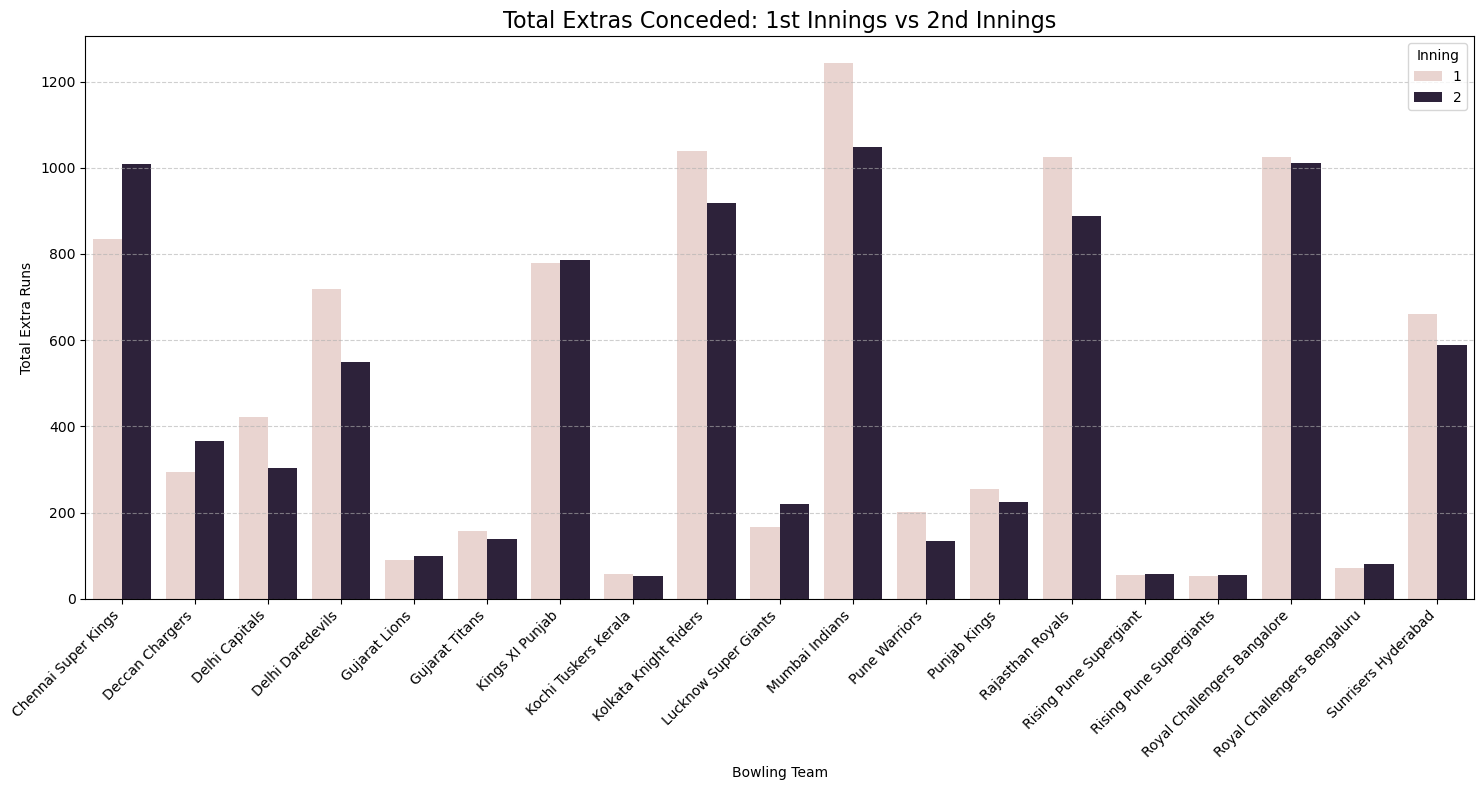

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

sns.barplot(data=team_extras, x='bowling_team', y='extra_runs', hue='inning')

plt.title('Total Extras Conceded: 1st Innings vs 2nd Innings', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Bowling Team')
plt.ylabel('Total Extra Runs')
plt.legend(title='Inning')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [9]:
type_breakdown = df[df['extra_runs'] > 0].groupby(['bowling_team', 'extras_type']).size().unstack(fill_value=0)
type_breakdown.head()

extras_type,byes,legbyes,noballs,penalty,wides
bowling_team,,,,,
Chennai Super Kings,60,421,97,0,946
Deccan Chargers,31,166,49,1,280
Delhi Capitals,24,143,47,0,387
Delhi Daredevils,39,324,86,0,550
Gujarat Lions,7,55,7,0,91
